In [1]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

TEST RUN RESULTS
Array: [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
D&C Results   -> Min: 0, Max: 9, Comparisons: 14
Naive Results -> Min: 0, Max: 9, Comparisons: 18



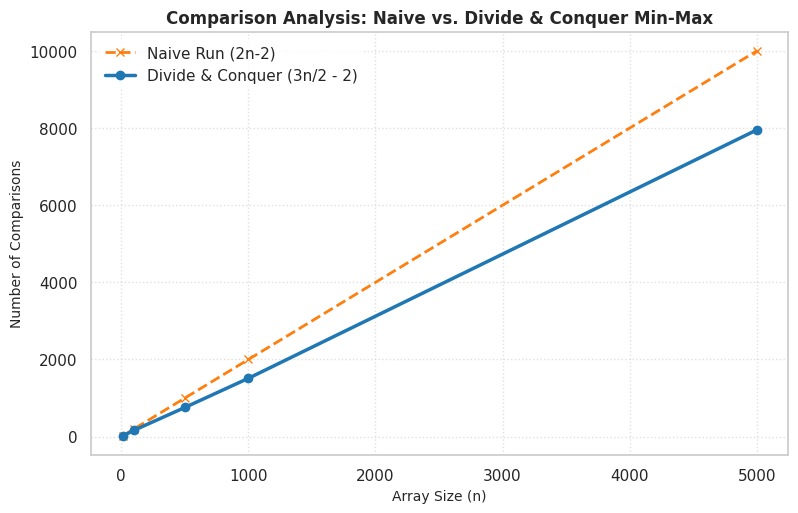

In [2]:
import random
import matplotlib.pyplot as plt

def min_max_dc(arr, low, high):
    """
    Divide and Conquer Min-Max
    Returns: (min_value, max_value, comparison_count)
    """
    
    if low == high:
        return arr[low], arr[low], 0
    
    
    if high == low + 1:
        if arr[low] < arr[high]:
            return arr[low], arr[high], 1
        else:
            return arr[high], arr[low], 1
            
    
    mid = (low + high) // 2
    
  
    l_min, l_max, l_comps = min_max_dc(arr, low, mid)
    r_min, r_max, r_comps = min_max_dc(arr, mid + 1, high)
    
  
    overall_min = l_min if l_min < r_min else r_min
    overall_max = l_max if l_max > r_max else r_max
    
    total_comps = l_comps + r_comps + 2
    return overall_min, overall_max, total_comps

def min_max_naive(arr):
    """
    Naive Sequential Min-Max
    Returns: (min_value, max_value, comparison_count)
    """
    mn, mx = arr[0], arr[0]
    comps = 0
    for x in arr[1:]:
        comps += 1
        if x < mn:
            mn = x
        comps += 1
        if x > mx:
            mx = x
    return mn, mx, comps


test_arr = [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
dc_min, dc_max, dc_total_comps = min_max_dc(test_arr, 0, len(test_arr) - 1)
naive_min, naive_max, naive_total_comps = min_max_naive(test_arr)

print("=" * 60)
print("TEST RUN RESULTS")
print("=" * 60)
print(f"Array: {test_arr}")
print(f"D&C Results   -> Min: {dc_min}, Max: {dc_max}, Comparisons: {dc_total_comps}")
print(f"Naive Results -> Min: {naive_min}, Max: {naive_max}, Comparisons: {naive_total_comps}")
print("=" * 60 + "\n")


sizes = [10, 100, 500, 1000, 5000]
dc_results = []
naive_results = []

for size in sizes:
   
    arr = [random.randint(1, 100000) for _ in range(size)]
    
  
    _, _, dc_comps = min_max_dc(arr, 0, len(arr) - 1)
    _, _, naive_comps = min_max_naive(arr)
    
    dc_results.append(dc_comps)
    naive_results.append(naive_comps)


plt.figure(figsize=(9, 5.5))
plt.plot(sizes, naive_results, marker='x', color='#ff7f0e', linestyle='--', linewidth=2, label='Naive Run (2n-2)')
plt.plot(sizes, dc_results, marker='o', color='#1f77b4', linewidth=2.5, label='Divide & Conquer (3n/2 - 2)')

plt.title('Comparison Analysis: Naive vs. Divide & Conquer Min-Max', fontsize=12, fontweight='bold')
plt.xlabel('Array Size (n)', fontsize=10)
plt.ylabel('Number of Comparisons', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.show()